In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully


In [4]:
# Load datasets
df_lpi = pd.read_csv('/Users/ashantimiller/latam-export-analysis/data/data:world_bank_lpi_latam_caribbean.csv')
df_trade = pd.read_csv('/Users/ashantimiller/latam-export-analysis/data/TradeData_3_24_2026_14_26_5.csv')

# Glimpse
print ("LPI Dataset Shape:", df_lpi.shape)
print ("Trade Dataset Sheape:", df_trade.shape)


LPI Dataset Shape: (222, 14)
Trade Dataset Sheape: (65, 47)


In [5]:
# Preview LPI dataset
print("=== LPI DATASET ===")
print(df_lpi.head())
print("\nColumns:", df_lpi.columns.tolist())

=== LPI DATASET ===
          Country Name Country Code  \
0  Trinidad and Tobago          TTO   
1  Trinidad and Tobago          TTO   
2  Trinidad and Tobago          TTO   
3  Trinidad and Tobago          TTO   
4  Trinidad and Tobago          TTO   

                                         Series Name     Series Code  \
0  Logistics performance index: Ability to track ...  LP.LPI.TRAC.XQ   
1  Logistics performance index: Competence and qu...  LP.LPI.LOGS.XQ   
2  Logistics performance index: Ease of arranging...  LP.LPI.ITRN.XQ   
3  Logistics performance index: Efficiency of cus...  LP.LPI.CUST.XQ   
4  Logistics performance index: Frequency with wh...  LP.LPI.TIME.XQ   

  2014 [YR2014] 2015 [YR2015] 2016 [YR2016] 2017 [YR2017] 2018 [YR2018]  \
0            ..            ..      2.279914            ..          2.27   
1            ..            ..      2.283842            ..          2.27   
2            ..            ..      2.308907            ..          2.59   
3           

In [6]:
# Preview Trade dataset
print("=== TRADE DATASET ===")
print(df_trade.head())
print("\nColumns:", df_trade.columns.tolist())

=== TRADE DATASET ===
  typeCode  freqCode  refPeriodId  refYear  refMonth  period reporterCode  \
C        A  20180101         2018       52      2018      32          ARG   
C        A  20180101         2018       52      2018      76          BRA   
C        A  20180101         2018       52      2018     152          CHL   
C        A  20180101         2018       52      2018     170          COL   
C        A  20180101         2018       52      2018     214          DOM   

      reporterISO reporterDesc flowCode  ...  netWgt isNetWgtEstimated  \
C       Argentina            X   Export  ...   False               0.0   
C          Brazil            X   Export  ...    True               0.0   
C           Chile            X   Export  ...    True               0.0   
C        Colombia            X   Export  ...    True               NaN   
C  Dominican Rep.            X   Export  ...   False               0.0   

  grossWgt  isGrossWgtEstimated      cifvalue      fobvalue primaryVal

In [7]:
# Keep only relevant columns from trade data
df_trade_clean = df_trade[[
    'reporterDesc',
    'reporterISO', 
    'refYear',
    'fobvalue'
]].copy()

# Rename for clarity
df_trade_clean.columns = ['country', 'iso_code', 'year', 'export_value_usd']

print(df_trade_clean.head(10))
print("\nShape:", df_trade_clean.shape)

  country        iso_code  year  export_value_usd
C       X       Argentina    52      6.155941e+10
C       X          Brazil    52      2.318895e+11
C       X           Chile    52      7.483798e+10
C       X        Colombia    52      4.183152e+10
C       X  Dominican Rep.    52      1.075801e+10
C       X         Jamaica    52      1.960740e+09
C       X          Mexico    52      4.506836e+11
C       X          Panama    52      1.148011e+10
C       X            Peru    52      4.801515e+10
C       X       Argentina    52      6.511533e+10

Shape: (65, 4)


In [8]:
# Check exact column positions
for i, col in enumerate(df_trade.columns):
    print(i, col)
    

0 typeCode
1 freqCode
2 refPeriodId
3 refYear
4 refMonth
5 period
6 reporterCode
7 reporterISO
8 reporterDesc
9 flowCode
10 flowDesc
11 partnerCode
12 partnerISO
13 partnerDesc
14 partner2Code
15 partner2ISO
16 partner2Desc
17 classificationCode
18 classificationSearchCode
19 isOriginalClassification
20 cmdCode
21 cmdDesc
22 aggrLevel
23 isLeaf
24 customsCode
25 customsDesc
26 mosCode
27 motCode
28 motDesc
29 qtyUnitCode
30 qtyUnitAbbr
31 qty
32 isQtyEstimated
33 altQtyUnitCode
34 altQtyUnitAbbr
35 altQty
36 isAltQtyEstimated
37 netWgt
38 isNetWgtEstimated
39 grossWgt
40 isGrossWgtEstimated
41 cifvalue
42 fobvalue
43 primaryValue
44 legacyEstimationFlag
45 isReported
46 isAggregate


In [9]:
# Keep only relevant columns using exact names
df_trade_clean = df_trade[[
    'reporterDesc',
    'reporterISO',
    'refYear',
    'fobvalue'
]].copy()

# Rename for clarity
df_trade_clean.columns = ['country', 'iso_code', 'year', 'export_value_usd']

# Reset index
df_trade_clean = df_trade_clean.reset_index(drop=True)

print(df_trade_clean.head(10))
print("\nShape:", df_trade_clean.shape)


  country        iso_code  year  export_value_usd
0       X       Argentina    52      6.155941e+10
1       X          Brazil    52      2.318895e+11
2       X           Chile    52      7.483798e+10
3       X        Colombia    52      4.183152e+10
4       X  Dominican Rep.    52      1.075801e+10
5       X         Jamaica    52      1.960740e+09
6       X          Mexico    52      4.506836e+11
7       X          Panama    52      1.148011e+10
8       X            Peru    52      4.801515e+10
9       X       Argentina    52      6.511533e+10

Shape: (65, 4)


In [10]:
# Check what's actually in the raw dataframe
print(df_trade[['reporterISO', 'reporterDesc', 'refYear']].head(10))


      reporterISO reporterDesc  refYear
C       Argentina            X       52
C          Brazil            X       52
C           Chile            X       52
C        Colombia            X       52
C  Dominican Rep.            X       52
C         Jamaica            X       52
C          Mexico            X       52
C          Panama            X       52
C            Peru            X       52
C       Argentina            X       52


In [12]:
# Read the file fresh and skip any problematic rows
df_trade_raw = pd.read_csv('/Users/ashantimiller/latam-export-analysis/data/TradeData_3_24_2026_14_26_5.csv', nrows=3)
print(df_trade_raw.to_string())


  typeCode  freqCode  refPeriodId  refYear  refMonth  period reporterCode reporterISO reporterDesc flowCode  flowDesc partnerCode partnerISO  partnerDesc partner2Code partner2ISO partner2Desc classificationCode  classificationSearchCode isOriginalClassification          cmdCode  cmdDesc  aggrLevel isLeaf customsCode  customsDesc  mosCode    motCode  motDesc  qtyUnitCode  qtyUnitAbbr    qty  isQtyEstimated  altQtyUnitCode  altQtyUnitAbbr  altQty  isAltQtyEstimated  netWgt  isNetWgtEstimated  grossWgt  isGrossWgtEstimated      cifvalue      fobvalue  primaryValue  legacyEstimationFlag  isReported  isAggregate
C        A  20180101         2018       52      2018      32          ARG   Argentina            X   Export         0         W00      World            0          W00       World           H5                 HS                      True                    TOTAL  All Commodities        0      False    C00   TOTAL CPC            0        0  TOTAL MOT       -1          NaN            0

In [14]:
# Reload trade data fresh with correct index
df_trade = pd.read_csv('/Users/ashantimiller/latam-export-analysis/data/TradeData_3_24_2026_14_26_5.csv')

# Now select the right columns
df_trade_clean = df_trade[[
    'reporterDesc',
    'reporterISO',
    'refYear',
    'fobvalue'
]].copy()

# Rename for clarity
df_trade_clean.columns = ['country', 'iso_code', 'year', 'export_value_usd']

print(df_trade_clean.head(10))
print("\nShape:", df_trade_clean.shape)


  country        iso_code  year  export_value_usd
C       X       Argentina    52      6.155941e+10
C       X          Brazil    52      2.318895e+11
C       X           Chile    52      7.483798e+10
C       X        Colombia    52      4.183152e+10
C       X  Dominican Rep.    52      1.075801e+10
C       X         Jamaica    52      1.960740e+09
C       X          Mexico    52      4.506836e+11
C       X          Panama    52      1.148011e+10
C       X            Peru    52      4.801515e+10
C       X       Argentina    52      6.511533e+10

Shape: (65, 4)


In [15]:
# Reload with explicit index handling
df_trade = pd.read_csv('/Users/ashantimiller/latam-export-analysis/data/TradeData_3_24_2026_14_26_5.csv', index_col=0)

# Check what it looks like now
print(df_trade[['reporterISO', 'reporterDesc', 'refYear', 'fobvalue']].head(5))

      reporterISO reporterDesc  refYear      fobvalue
C       Argentina            X       52  6.155941e+10
C          Brazil            X       52  2.318895e+11
C           Chile            X       52  7.483798e+10
C        Colombia            X       52  4.183152e+10
C  Dominican Rep.            X       52  1.075801e+10


In [16]:
# Reload and skip the bad index column
df_trade = pd.read_csv('/Users/ashantimiller/latam-export-analysis/data/TradeData_3_24_2026_14_26_5.csv')

# Check the actual values in each column we care about
print("reporterCode values:", df_trade['reporterCode'].head().tolist())
print("reporterISO values:", df_trade['reporterISO'].head().tolist())
print("reporterDesc values:", df_trade['reporterDesc'].head().tolist())
print("refYear values:", df_trade['refYear'].head().tolist())


reporterCode values: ['ARG', 'BRA', 'CHL', 'COL', 'DOM']
reporterISO values: ['Argentina', 'Brazil', 'Chile', 'Colombia', 'Dominican Rep.']
reporterDesc values: ['X', 'X', 'X', 'X', 'X']
refYear values: [52, 52, 52, 52, 52]


In [17]:
# Use columns that actually contain the right data
df_trade_clean = df_trade[[
    'reporterISO',
    'reporterCode',
    'freqCode',
    'fobvalue'
]].copy()

# Rename correctly based on what the data actually contains
df_trade_clean.columns = ['country', 'iso_code', 'year', 'export_value_usd']

print(df_trade_clean.head(10))


          country iso_code      year  export_value_usd
C       Argentina      ARG  20180101      6.155941e+10
C          Brazil      BRA  20180101      2.318895e+11
C           Chile      CHL  20180101      7.483798e+10
C        Colombia      COL  20180101      4.183152e+10
C  Dominican Rep.      DOM  20180101      1.075801e+10
C         Jamaica      JAM  20180101      1.960740e+09
C          Mexico      MEX  20180101      4.506836e+11
C          Panama      PAN  20180101      1.148011e+10
C            Peru      PER  20180101      4.801515e+10
C       Argentina      ARG  20190101      6.511533e+10


In [18]:
# Fix the year column and reset index
df_trade_clean = df_trade_clean.reset_index(drop=True)
df_trade_clean['year'] = df_trade_clean['year'].astype(str).str[:4].astype(int)

print(df_trade_clean.head(10))
print("\nUnique years:", df_trade_clean['year'].unique())
print("Unique countries:", df_trade_clean['country'].unique())

          country iso_code  year  export_value_usd
0       Argentina      ARG  2018      6.155941e+10
1          Brazil      BRA  2018      2.318895e+11
2           Chile      CHL  2018      7.483798e+10
3        Colombia      COL  2018      4.183152e+10
4  Dominican Rep.      DOM  2018      1.075801e+10
5         Jamaica      JAM  2018      1.960740e+09
6          Mexico      MEX  2018      4.506836e+11
7          Panama      PAN  2018      1.148011e+10
8            Peru      PER  2018      4.801515e+10
9       Argentina      ARG  2019      6.511533e+10

Unique years: [2018 2019 2020 2021 2022 2023 2024 2025]
Unique countries: ['Argentina' 'Brazil' 'Chile' 'Colombia' 'Dominican Rep.' 'Jamaica'
 'Mexico' 'Panama' 'Peru']


In [20]:
# Preview again for LPI Dataset

print("=== LPI DATASET ===")
print(df_lpi.head())


=== LPI DATASET ===
          Country Name Country Code  \
0  Trinidad and Tobago          TTO   
1  Trinidad and Tobago          TTO   
2  Trinidad and Tobago          TTO   
3  Trinidad and Tobago          TTO   
4  Trinidad and Tobago          TTO   

                                         Series Name     Series Code  \
0  Logistics performance index: Ability to track ...  LP.LPI.TRAC.XQ   
1  Logistics performance index: Competence and qu...  LP.LPI.LOGS.XQ   
2  Logistics performance index: Ease of arranging...  LP.LPI.ITRN.XQ   
3  Logistics performance index: Efficiency of cus...  LP.LPI.CUST.XQ   
4  Logistics performance index: Frequency with wh...  LP.LPI.TIME.XQ   

  2014 [YR2014] 2015 [YR2015] 2016 [YR2016] 2017 [YR2017] 2018 [YR2018]  \
0            ..            ..      2.279914            ..          2.27   
1            ..            ..      2.283842            ..          2.27   
2            ..            ..      2.308907            ..          2.59   
3           

In [24]:
# Replacing empty columns wuth nan

df_lpi = df_lpi.replace('..', np.nan)

# Checking
print(df_lpi.head())

          Country Name Country Code  \
0  Trinidad and Tobago          TTO   
1  Trinidad and Tobago          TTO   
2  Trinidad and Tobago          TTO   
3  Trinidad and Tobago          TTO   
4  Trinidad and Tobago          TTO   

                                         Series Name     Series Code  \
0  Logistics performance index: Ability to track ...  LP.LPI.TRAC.XQ   
1  Logistics performance index: Competence and qu...  LP.LPI.LOGS.XQ   
2  Logistics performance index: Ease of arranging...  LP.LPI.ITRN.XQ   
3  Logistics performance index: Efficiency of cus...  LP.LPI.CUST.XQ   
4  Logistics performance index: Frequency with wh...  LP.LPI.TIME.XQ   

  2014 [YR2014]  2015 [YR2015] 2016 [YR2016]  2017 [YR2017] 2018 [YR2018]  \
0           NaN            NaN      2.279914            NaN          2.27   
1           NaN            NaN      2.283842            NaN          2.27   
2           NaN            NaN      2.308907            NaN          2.59   
3           NaN         

In [25]:
df_lpi.columns = df_lpi.columns.str.replace(r' \[YR\d+\]', '', regex=True)
print(df_lpi.columns.tolist())

['Country Name', 'Country Code', 'Series Name', 'Series Code', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']


In [26]:
# Step 1: Melt year columns into rows
df_lpi_melted = df_lpi.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name'],
    value_vars=['2014','2015','2016','2017','2018','2019','2020','2021','2022','2023'],
    var_name='year',
    value_name='score'
)

print(df_lpi_melted.head(10))
print("\nShape:", df_lpi_melted.shape)


                     Country Name Country Code  \
0             Trinidad and Tobago          TTO   
1             Trinidad and Tobago          TTO   
2             Trinidad and Tobago          TTO   
3             Trinidad and Tobago          TTO   
4             Trinidad and Tobago          TTO   
5             Trinidad and Tobago          TTO   
6             Trinidad and Tobago          TTO   
7  St. Vincent and the Grenadines          VCT   
8  St. Vincent and the Grenadines          VCT   
9  St. Vincent and the Grenadines          VCT   

                                         Series Name  year score  
0  Logistics performance index: Ability to track ...  2014   NaN  
1  Logistics performance index: Competence and qu...  2014   NaN  
2  Logistics performance index: Ease of arranging...  2014   NaN  
3  Logistics performance index: Efficiency of cus...  2014   NaN  
4  Logistics performance index: Frequency with wh...  2014   NaN  
5  Logistics performance index: Overall (1=low 

In [28]:
# Convert score to numeric
df_lpi_melted['score'] = pd.to_numeric(df_lpi_melted['score'], errors='coerce')

# Now run the pivot
df_lpi_clean = df_lpi_melted.pivot_table(
    index=['Country Name', 'Country Code', 'year'],
    columns='Series Name',
    values='score'
).reset_index()

# Simplify column names
df_lpi_clean.columns.name = None
df_lpi_clean.columns = [
    'country', 'iso_code', 'year',
    'tracking', 'competence', 'shipments',
    'customs', 'timeliness', 'lpi_overall', 'infrastructure'
]

print(df_lpi_clean.head())
print("\nShape:", df_lpi_clean.shape)

               country iso_code  year  tracking  competence  shipments  \
0  Antigua and Barbuda      ATG  2022  3.200000    2.900000   2.900000   
1            Argentina      ARG  2022  2.900000    2.700000   2.700000   
2            Argentina      ARG  2014  3.150335    2.930554   2.957428   
3            Argentina      ARG  2016  3.260731    2.825233   2.759638   
4            Argentina      ARG  2018  3.050000    2.780000   2.920000   

    customs  timeliness  lpi_overall  infrastructure  
0  2.200000    3.400000     2.900000        2.700000  
1  2.700000    3.100000     2.800000        2.800000  
2  2.546248    3.492036     2.986475        2.831158  
3  2.628572    3.470985     2.962629        2.856412  
4  2.420000    3.370000     2.890000        2.770000  

Shape: (91, 10)


In [29]:
print("Unique countries:", df_lpi_clean['country'].nunique())
print("Unique years:", df_lpi_clean['year'].unique())
print("\nCountries:", df_lpi_clean['country'].unique())

Unique countries: 25
Unique years: ['2022' '2014' '2016' '2018']

Countries: ['Antigua and Barbuda' 'Argentina' 'Bahamas, The' 'Bolivia' 'Brazil'
 'Chile' 'Colombia' 'Costa Rica' 'Cuba' 'Dominican Republic' 'Ecuador'
 'El Salvador' 'Grenada' 'Guyana' 'Haiti' 'Honduras' 'Jamaica' 'Mexico'
 'Nicaragua' 'Panama' 'Paraguay' 'Peru' 'Trinidad and Tobago' 'Uruguay'
 'Venezuela, RB']


In [30]:
lpi_countries = set(df_lpi_clean['country'].unique())
trade_countries = set(df_trade_clean['country'].unique())

print("Countries in BOTH datasets:")
print(lpi_countries.intersection(trade_countries))

print("\nCountries in Trade but NOT in LPI:")
print(trade_countries - lpi_countries)

Countries in BOTH datasets:
{'Brazil', 'Panama', 'Mexico', 'Colombia', 'Chile', 'Argentina', 'Jamaica', 'Peru'}

Countries in Trade but NOT in LPI:
{'Dominican Rep.'}


In [32]:
# Changing Dominican Rep to Correct Name
df_trade_clean['country'] = df_trade_clean['country'].str.replace('Dominican Rep.', 'Dominican Republic')

#Check
print(df_trade_clean['country'].unique())

['Argentina' 'Brazil' 'Chile' 'Colombia' 'Dominican Republic' 'Jamaica'
 'Mexico' 'Panama' 'Peru']


In [33]:
# Merge LPI and Trade data
df_merged = pd.merge(
    df_lpi_clean,
    df_trade_clean,
    on='country',
    how='inner'
)

print(df_merged.head())
print("\nShape:", df_merged.shape)
print("\nColumns:", df_merged.columns.tolist())

     country iso_code_x year_x  tracking  competence  shipments  customs  \
0  Argentina        ARG   2022       2.9         2.7        2.7      2.7   
1  Argentina        ARG   2022       2.9         2.7        2.7      2.7   
2  Argentina        ARG   2022       2.9         2.7        2.7      2.7   
3  Argentina        ARG   2022       2.9         2.7        2.7      2.7   
4  Argentina        ARG   2022       2.9         2.7        2.7      2.7   

   timeliness  lpi_overall  infrastructure iso_code_y  year_y  \
0         3.1          2.8             2.8        ARG    2018   
1         3.1          2.8             2.8        ARG    2019   
2         3.1          2.8             2.8        ARG    2020   
3         3.1          2.8             2.8        ARG    2021   
4         3.1          2.8             2.8        ARG    2022   

   export_value_usd  
0      6.155941e+10  
1      6.511533e+10  
2      5.488382e+10  
3      7.793431e+10  
4      8.844572e+10  

Shape: (260, 13)

C

In [34]:
df_merged = df_merged.drop(columns=['iso_code_y', 'year_y'])

print(df_merged.columns.tolist())
print("\nShape:", df_merged.shape)

['country', 'iso_code_x', 'year_x', 'tracking', 'competence', 'shipments', 'customs', 'timeliness', 'lpi_overall', 'infrastructure', 'export_value_usd']

Shape: (260, 11)


In [35]:
#rename
df_merged = df_merged.rename(columns={'iso_code_x': 'iso_code', 'year_x': 'year'})
print(df_merged.columns.tolist())

['country', 'iso_code', 'year', 'tracking', 'competence', 'shipments', 'customs', 'timeliness', 'lpi_overall', 'infrastructure', 'export_value_usd']


In [36]:
print("=== FINAL DATASET SUMMARY ===")
print("\nShape:", df_merged.shape)
print("\nMissing values:")
print(df_merged.isnull().sum())
print("\nSample:")
print(df_merged.head())

=== FINAL DATASET SUMMARY ===

Shape: (260, 11)

Missing values:
country             0
iso_code            0
year                0
tracking            0
competence          0
shipments           0
customs             0
timeliness          0
lpi_overall         0
infrastructure      0
export_value_usd    0
dtype: int64

Sample:
     country iso_code  year  tracking  competence  shipments  customs  \
0  Argentina      ARG  2022       2.9         2.7        2.7      2.7   
1  Argentina      ARG  2022       2.9         2.7        2.7      2.7   
2  Argentina      ARG  2022       2.9         2.7        2.7      2.7   
3  Argentina      ARG  2022       2.9         2.7        2.7      2.7   
4  Argentina      ARG  2022       2.9         2.7        2.7      2.7   

   timeliness  lpi_overall  infrastructure  export_value_usd  
0         3.1          2.8             2.8      6.155941e+10  
1         3.1          2.8             2.8      6.511533e+10  
2         3.1          2.8             2.8 

In [37]:
# Checking Data is still loaded

print("LPI shape:", df_lpi_clean.shape)
print("Trade shape:", df_trade_clean.shape)
print("Merged shape:", df_merged.shape)

LPI shape: (91, 10)
Trade shape: (65, 4)
Merged shape: (260, 11)


In [38]:
import math

def haversine(lat1, lon1, lat2, lon2):
    # Radius of the Earth in kilometers
    R = 6371
    
    # Convert degrees to radians
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    c = 2 * math.asin(math.sqrt(a))
    
    return R * c

# Test it — distance from Panama City to Mexico City
test = haversine(8.9936, -79.5197, 19.4326, -99.1332)
print(f"Distance Panama to Mexico City: {test:.0f} km")

Distance Panama to Mexico City: 2408 km


In [39]:
# Panama Canal coordinates
PANAMA_LAT = 9.08
PANAMA_LON = -79.68

# Main port or capital coordinates for each country
country_coords = {
    'Argentina':           (-34.6037, -58.3816),  # Buenos Aires
    'Brazil':              (-23.5505, -46.6333),  # Sao Paulo
    'Chile':               (-33.4489, -70.6693),  # Santiago
    'Colombia':            (10.3910,  -75.4794),  # Cartagena (main port)
    'Dominican Republic':  (18.4861,  -69.9312),  # Santo Domingo
    'Jamaica':             (17.9970,  -76.7936),  # Kingston
    'Mexico':              (19.4326,  -99.1332),  # Mexico City
    'Panama':              (8.9936,   -79.5197),  # Panama City
    'Peru':                (-12.0464, -77.0428),  # Lima
}

# Calculate distance for each country
results = []
for country, (lat, lon) in country_coords.items():
    dist = haversine(PANAMA_LAT, PANAMA_LON, lat, lon)
    results.append({'country': country, 'distance_to_canal_km': round(dist)})

# Convert to dataframe
df_distances = pd.DataFrame(results)
df_distances = df_distances.sort_values('distance_to_canal_km')

print(df_distances)

              country  distance_to_canal_km
7              Panama                    20
3            Colombia                   483
5             Jamaica                  1039
4  Dominican Republic                  1483
8                Peru                  2367
6              Mexico                  2388
2               Chile                  4824
1              Brazil                  5106
0           Argentina                  5350


In [40]:
# Merge distances into main dataset
df_merged = pd.merge(
    df_merged,
    df_distances,
    on='country',
    how='left'
)

print(df_merged.columns.tolist())
print("\nShape:", df_merged.shape)
print("\nSample:")
print(df_merged[['country', 'distance_to_canal_km', 'lpi_overall', 'export_value_usd']].head(10))


['country', 'iso_code', 'year', 'tracking', 'competence', 'shipments', 'customs', 'timeliness', 'lpi_overall', 'infrastructure', 'export_value_usd', 'distance_to_canal_km']

Shape: (260, 12)

Sample:
     country  distance_to_canal_km  lpi_overall  export_value_usd
0  Argentina                  5350     2.800000      6.155941e+10
1  Argentina                  5350     2.800000      6.511533e+10
2  Argentina                  5350     2.800000      5.488382e+10
3  Argentina                  5350     2.800000      7.793431e+10
4  Argentina                  5350     2.800000      8.844572e+10
5  Argentina                  5350     2.800000      6.678852e+10
6  Argentina                  5350     2.800000      7.970321e+10
7  Argentina                  5350     2.986475      6.155941e+10
8  Argentina                  5350     2.986475      6.511533e+10
9  Argentina                  5350     2.986475      5.488382e+10


In [41]:
# Filter LPI to only 2018 and 2022
df_lpi_filtered = df_lpi_clean[df_lpi_clean['year'].isin(['2018', '2022'])]

# Filter trade to only 2018 and 2022
df_trade_filtered = df_trade_clean[df_trade_clean['year'].isin([2018, 2022])]

# Check counts
print("LPI filtered shape:", df_lpi_filtered.shape)
print("Trade filtered shape:", df_trade_filtered.shape)
print("\nLPI years:", df_lpi_filtered['year'].unique())
print("Trade years:", df_trade_filtered['year'].unique())

LPI filtered shape: (46, 10)
Trade filtered shape: (18, 4)

LPI years: ['2022' '2018']
Trade years: [2018 2022]


In [42]:
# Make year the same data type in both datasets
df_lpi_filtered = df_lpi_filtered.copy()
df_trade_filtered = df_trade_filtered.copy()

df_lpi_filtered['year'] = df_lpi_filtered['year'].astype(int)
df_trade_filtered['year'] = df_trade_filtered['year'].astype(int)

# Merge on both country AND year this time
df_merged_clean = pd.merge(
    df_lpi_filtered,
    df_trade_filtered,
    on=['country', 'year'],
    how='inner'
)

# Add distances
df_merged_clean = pd.merge(
    df_merged_clean,
    df_distances,
    on='country',
    how='left'
)

print("Shape:", df_merged_clean.shape)
print("\nSample:")
print(df_merged_clean[['country', 'year', 'distance_to_canal_km', 'lpi_overall', 'export_value_usd']].head(10))

Shape: (18, 13)

Sample:
              country  year  distance_to_canal_km  lpi_overall  \
0           Argentina  2022                  5350         2.80   
1           Argentina  2018                  5350         2.89   
2              Brazil  2022                  5106         3.20   
3              Brazil  2018                  5106         2.99   
4               Chile  2022                  4824         3.00   
5               Chile  2018                  4824         3.32   
6            Colombia  2022                   483         2.90   
7            Colombia  2018                   483         2.94   
8  Dominican Republic  2022                  1483         2.60   
9  Dominican Republic  2018                  1483         2.66   

   export_value_usd  
0      8.844572e+10  
1      6.155941e+10  
2      3.344631e+11  
3      2.318895e+11  
4      9.855701e+10  
5      7.483798e+10  
6      5.691014e+10  
7      4.183152e+10  
8      9.836347e+09  
9      1.075801e+10  


In [43]:
print("Final dataset shape:", df_merged_clean.shape)
print("\nCountries:", df_merged_clean['country'].unique())
print("\nYears:", df_merged_clean['year'].unique())
print("\nMissing values:")
print(df_merged_clean.isnull().sum())

Final dataset shape: (18, 13)

Countries: ['Argentina' 'Brazil' 'Chile' 'Colombia' 'Dominican Republic' 'Jamaica'
 'Mexico' 'Panama' 'Peru']

Years: [2022 2018]

Missing values:
country                 0
iso_code_x              0
year                    0
tracking                0
competence              0
shipments               0
customs                 0
timeliness              0
lpi_overall             0
infrastructure          0
iso_code_y              0
export_value_usd        0
distance_to_canal_km    0
dtype: int64


In [44]:
# Drop duplicate iso code column and rename
df_merged_clean = df_merged_clean.drop(columns=['iso_code_y'])
df_merged_clean = df_merged_clean.rename(columns={'iso_code_x': 'iso_code'})

# Save to CSV
df_merged_clean.to_csv('/Users/ashantimiller/latam-export-analysis/data/merged_clean.csv', index=False)

print("Columns:", df_merged_clean.columns.tolist())
print("\nMaster dataset saved!")


Columns: ['country', 'iso_code', 'year', 'tracking', 'competence', 'shipments', 'customs', 'timeliness', 'lpi_overall', 'infrastructure', 'export_value_usd', 'distance_to_canal_km']

Master dataset saved!


In [46]:
# Correlation matrix of our key variables
correlation_vars = ['lpi_overall', 'customs', 'infrastructure', 
                    'timeliness', 'distance_to_canal_km', 'export_value_usd']

corr_matrix = df_merged_clean[correlation_vars].corr()

print("=== CORRELATION MATRIX ===")
print(corr_matrix.round(2))






=== CORRELATION MATRIX ===
                      lpi_overall  customs  infrastructure  timeliness  \
lpi_overall                  1.00     0.78            0.84        0.84   
customs                      0.78     1.00            0.73        0.59   
infrastructure               0.84     0.73            1.00        0.66   
timeliness                   0.84     0.59            0.66        1.00   
distance_to_canal_km         0.25     0.22            0.21        0.32   
export_value_usd             0.29     0.06            0.26        0.44   

                      distance_to_canal_km  export_value_usd  
lpi_overall                           0.25              0.29  
customs                               0.22              0.06  
infrastructure                        0.21              0.26  
timeliness                            0.32              0.44  
distance_to_canal_km                  1.00              0.31  
export_value_usd                      0.31              1.00  


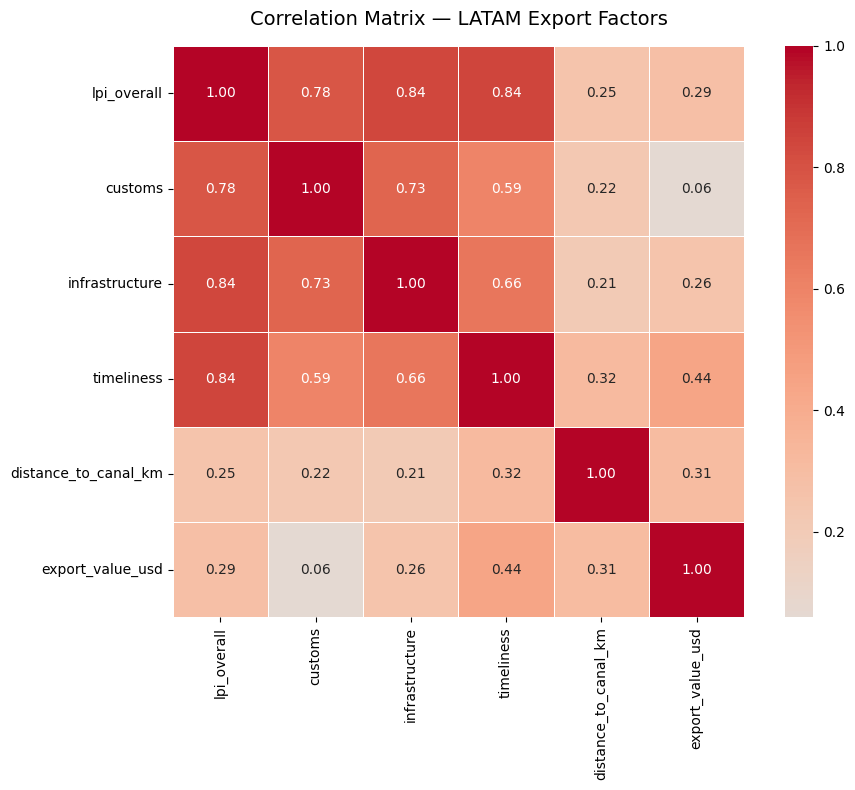

Chart saved!


In [47]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix — LATAM Export Factors', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('/Users/ashantimiller/latam-export-analysis/visuals/correlation_heatmap.png', dpi=150)
plt.show()

print("Chart saved!")

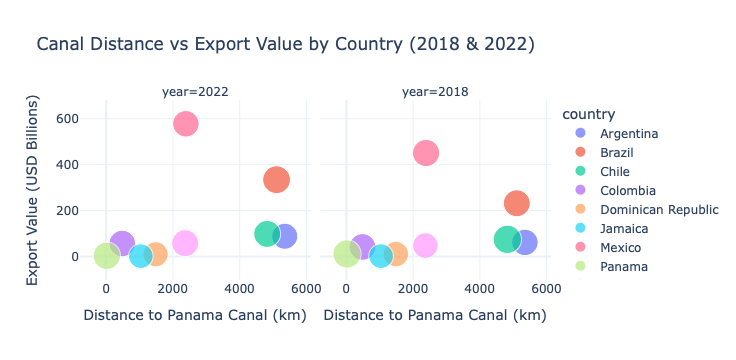

Chart saved!


In [48]:
# Convert export value to billions for readability
df_merged_clean['export_billions'] = df_merged_clean['export_value_usd'] / 1e9

# Create scatter plot
fig = px.scatter(
    df_merged_clean,
    x='distance_to_canal_km',
    y='export_billions',
    color='country',
    size='lpi_overall',
    hover_name='country',
    hover_data=['year', 'lpi_overall', 'customs', 'timeliness'],
    facet_col='year',
    title='Canal Distance vs Export Value by Country (2018 & 2022)',
    labels={
        'distance_to_canal_km': 'Distance to Panama Canal (km)',
        'export_billions': 'Export Value (USD Billions)',
        'lpi_overall': 'LPI Score'
    },
    template='plotly_white'
)

fig.write_html('/Users/ashantimiller/latam-export-analysis/visuals/scatter_distance_exports.html')
fig.show()

print("Chart saved!")

In [49]:
print(df_merged_clean[df_merged_clean['country'] == 'Peru'][['country', 'year', 'export_value_usd', 'distance_to_canal_km']])

   country  year  export_value_usd  distance_to_canal_km
16    Peru  2022      5.817242e+10                  2367
17    Peru  2018      4.801515e+10                  2367


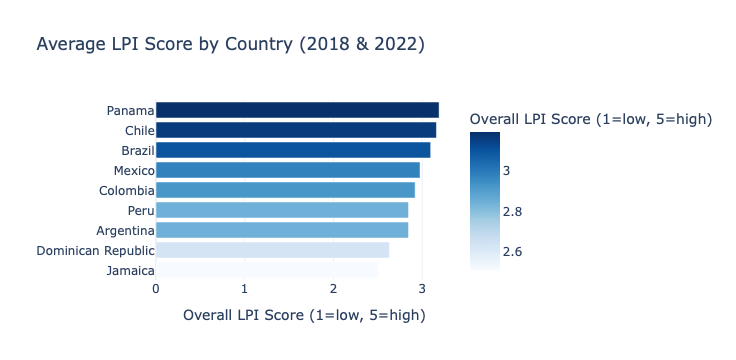

Chart saved!


In [51]:
# Average LPI scores across both years per country
df_lpi_avg = df_merged_clean.groupby('country')[['lpi_overall', 'customs', 'infrastructure', 'timeliness']].mean().reset_index()
df_lpi_avg = df_lpi_avg.sort_values('lpi_overall', ascending=True)

# Create horizontal bar chart
fig2 = px.bar(
    df_lpi_avg,
    x='lpi_overall',
    y='country',
    orientation='h',
    color='lpi_overall',
    color_continuous_scale='Blues',
    title='Average LPI Score by Country (2018 & 2022)',
    labels={
        'lpi_overall': 'Overall LPI Score (1=low, 5=high)',
        'country': ''
    },
    template='plotly_white'
)

fig2.write_html('/Users/ashantimiller/latam-export-analysis/visuals/lpi_by_country.html')
fig2.show()

print("Chart saved!")
                

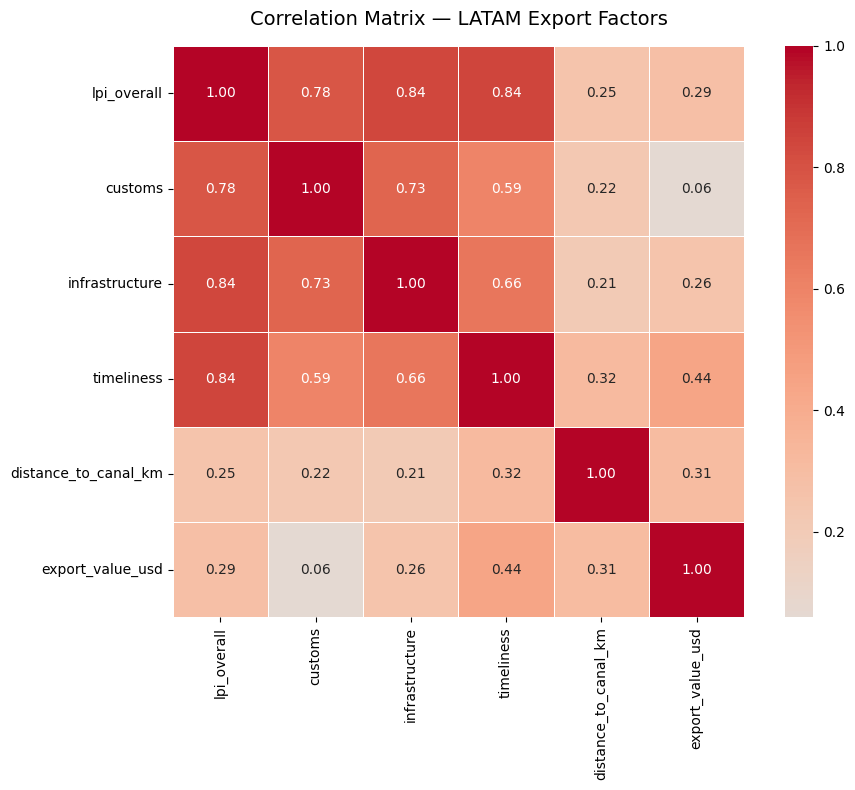

Chart saved!


In [52]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix — LATAM Export Factors', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('/Users/ashantimiller/latam-export-analysis/visuals/correlation_heatmap.png', dpi=150)
plt.show()

print("Chart saved!")

In [53]:
# Average export value per country across both years
df_map = df_merged_clean.groupby(['country', 'iso_code'])['export_billions'].mean().reset_index()
df_map.columns = ['country', 'iso_code', 'avg_export_billions']

print(df_map.sort_values('avg_export_billions', ascending=False))

              country iso_code  avg_export_billions
6              Mexico      MEX           514.207180
1              Brazil      BRA           283.176301
2               Chile      CHL            86.697493
0           Argentina      ARG            75.002563
8                Peru      PER            53.093785
3            Colombia      COL            49.370828
4  Dominican Republic      DOM            10.297179
7              Panama      PAN             7.566131
5             Jamaica      JAM             1.931078


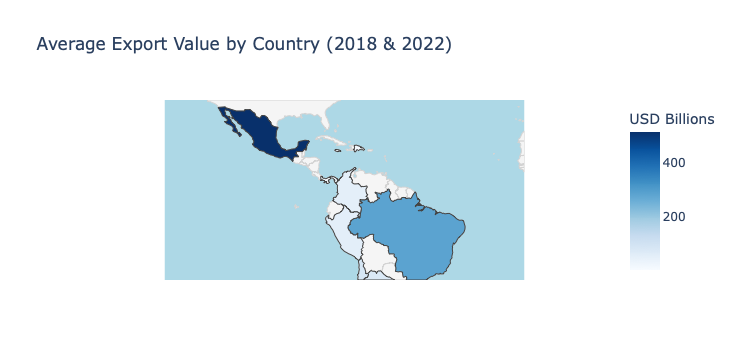

Map saved!


In [54]:
fig3 = px.choropleth(
    df_map,
    locations='iso_code',
    color='avg_export_billions',
    hover_name='country',
    hover_data={'avg_export_billions': ':.1f', 'iso_code': False},
    color_continuous_scale='Blues',
    scope='south america',
    title='Average Export Value by Country (2018 & 2022)',
    labels={'avg_export_billions': 'Avg Export Value (USD Billions)'}
)

# Expand scope to include Caribbean and Mexico
fig3.update_geos(
    scope='world',
    center={"lat": 5, "lon": -75},
    projection_scale=3,
    visible=False,
    showcountries=True,
    countrycolor='lightgray',
    showland=True,
    landcolor='whitesmoke',
    showocean=True,
    oceancolor='lightblue'
)

fig3.update_layout(
    geo=dict(showframe=False),
    coloraxis_colorbar=dict(title='USD Billions')
)

fig3.write_html('/Users/ashantimiller/latam-export-analysis/visuals/choropleth_map.html')
fig3.show()

print("Map saved!")

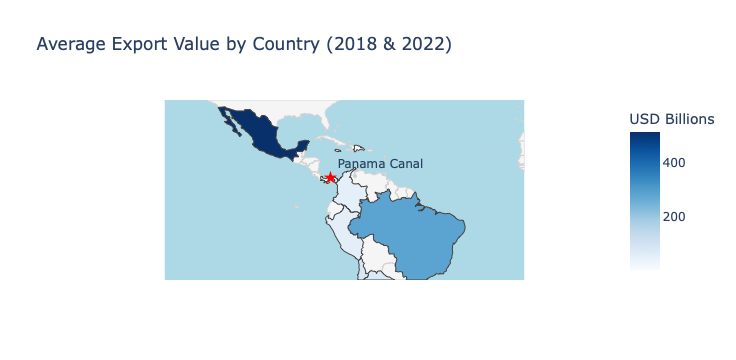

Map updated!


In [55]:
fig3.add_scattergeo(
    lat=[9.08],
    lon=[-79.68],
    mode='markers+text',
    marker=dict(size=10, color='red', symbol='star'),
    text=['Panama Canal'],
    textposition='top right',
    name='Panama Canal'
)

fig3.show()
fig3.write_html('/Users/ashantimiller/latam-export-analysis/visuals/choropleth_map.html')
print("Map updated!")